<figure>
  <IMG SRC="https://upload.wikimedia.org/wikipedia/commons/thumb/d/d5/Fachhochschule_Südwestfalen_20xx_logo.svg/320px-Fachhochschule_Südwestfalen_20xx_logo.svg.png" WIDTH=250 ALIGN="right">
</figure>

# Machine Learning
### Sommersemester 2026
Prof. Dr. Stefan Goetze

## Aufgabe zur Logistischen Regression

### Aufgabe: Kreditbewertung

Der Datensatz *Kreditscoring zur Klassifikation von Kreditnehmern. 2010. Open Data LMU. (https://doi.org/10.5282/ubm/data.23)* beinhaltet 1000 Datensätze, die Vergaben von Privatkrediten beschreiben.
Die Spalten beschreiben verschiedene Merkmale, die die Art des Kredits sowie die Eigenschaften der Kunden beschreiben.
Beispiele sind Höhe und Laufzeiten der Darlehn sowie das Alter und das Beschäftigungsverhältnis der Kreditnehmer.
Die binäre Zielgröße (auch *Dummy Variable* genannt) bildet die Spalte `kredit`.
Der Wert `1` bedeutet, dass für den entsprechenden Datenpunkt der Kredit zurückgezahlt wurde.
Entsprechend bedeutet `kredit=0`, dass der Kredit nicht ordnungsgemäß zurückgezahlt wurde.

Aufgrund dieser Datenbasis kann nun ein System entwickelt werden, dass für eine anstehende Kreditvergabe vorhersagt, ob der Kredit zurückgezalt wird.

Wir importieren zuerst die Pandas Bibliothek und laden den Datensatz `kredit.csv` in einen `DataFrame`.

In [19]:
import pandas as pd
import os
import urllib.request

url = "https://github.com/fhswf/aki-ml/raw/main/p3/kredit.csv"
dfile = "./kredit.csv"

if not os.path.isfile(dfile):
    urllib.request.urlretrieve(url, dfile)

In [20]:
import pandas as pd
df = pd.read_csv("kredit.csv")
df.head(10)

,kredit,laufkont,laufzeit,moral,verw,hoehe,sparkont,beszeit,rate,famges,...,wohnzeit,verm,alter,weitkred,wohn,bishkred,beruf,pers,telef,gastarb
0,1,1,18,4,2,1049,1,2,4,2,...,4,2,21,3,1,1,3,1,1,1
1,1,1,9,4,0,2799,1,3,2,3,...,2,1,36,3,1,2,3,2,1,1
2,1,2,12,2,9,841,2,4,2,2,...,4,1,23,3,1,1,2,1,1,1
3,1,1,12,4,0,2122,1,3,3,3,...,2,1,39,3,1,2,2,2,1,2
4,1,1,12,4,0,2171,1,3,4,3,...,4,2,38,1,2,2,2,1,1,2
5,1,1,10,4,0,2241,1,2,1,3,...,3,1,48,3,1,2,2,2,1,2
6,1,1,8,4,0,3398,1,4,1,3,...,4,1,39,3,2,2,2,1,1,2
7,1,1,6,4,0,1361,1,2,2,3,...,4,1,40,3,2,1,2,2,1,2
8,1,4,18,4,3,1098,1,1,4,2,...,4,3,65,3,2,2,1,1,1,1
9,1,2,24,2,3,3758,3,1,1,2,...,4,4,23,3,1,1,1,1,1,1


Mit `df.info()` und `df.describe()` erhalten wir einige Informationen über den Datensatz.

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   kredit    1000 non-null   int64
 1   laufkont  1000 non-null   int64
 2   laufzeit  1000 non-null   int64
 3   moral     1000 non-null   int64
 4   verw      1000 non-null   int64
 5   hoehe     1000 non-null   int64
 6   sparkont  1000 non-null   int64
 7   beszeit   1000 non-null   int64
 8   rate      1000 non-null   int64
 9   famges    1000 non-null   int64
 10  buerge    1000 non-null   int64
 11  wohnzeit  1000 non-null   int64
 12  verm      1000 non-null   int64
 13  alter     1000 non-null   int64
 14  weitkred  1000 non-null   int64
 15  wohn      1000 non-null   int64
 16  bishkred  1000 non-null   int64
 17  beruf     1000 non-null   int64
 18  pers      1000 non-null   int64
 19  telef     1000 non-null   int64
 20  gastarb   1000 non-null   int64
dtypes: int64(21)
memory usage: 164.2 KB


In [22]:
df.describe()

,kredit,laufkont,laufzeit,moral,verw,hoehe,sparkont,beszeit,rate,famges,...,wohnzeit,verm,alter,weitkred,wohn,bishkred,beruf,pers,telef,gastarb
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.00000,...,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.700000,2.577000,20.903000,2.54500,2.828000,3271.24800,2.105000,3.384000,2.973000,2.68200,...,2.845000,2.358000,35.54200,2.675000,1.928000,1.407000,2.904000,1.155000,1.404000,1.037000
std,0.458487,1.257638,12.058814,1.08312,2.744439,2822.75176,1.580023,1.208306,1.118715,0.70808,...,1.103718,1.050209,11.35267,0.705601,0.530186,0.577654,0.653614,0.362086,0.490943,0.188856
min,0.000000,1.000000,4.000000,0.00000,0.000000,250.00000,1.000000,1.000000,1.000000,1.00000,...,1.000000,1.000000,19.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,1.000000,12.000000,2.00000,1.000000,1365.50000,1.000000,3.000000,2.000000,2.00000,...,2.000000,1.000000,27.00000,3.000000,2.000000,1.000000,3.000000,1.000000,1.000000,1.000000
50%,1.000000,2.000000,18.000000,2.00000,2.000000,2319.50000,1.000000,3.000000,3.000000,3.00000,...,3.000000,2.000000,33.00000,3.000000,2.000000,1.000000,3.000000,1.000000,1.000000,1.000000
75%,1.000000,4.000000,24.000000,4.00000,3.000000,3972.25000,3.000000,5.000000,4.000000,3.00000,...,4.000000,3.000000,42.00000,3.000000,2.000000,2.000000,3.000000,1.000000,2.000000,1.000000
max,1.000000,4.000000,72.000000,4.00000,10.000000,18424.00000,5.000000,5.000000,4.000000,4.00000,...,4.000000,4.000000,75.00000,3.000000,3.000000,4.000000,4.000000,2.000000,2.000000,2.000000


Wir teilen nun die kompletten Daten in einen Trainings- und einen Test-Datensatz auf.
Dazu kann man die Methode `train_test_split()` aus dem Modul `sklearn.model_selection` verwendet werden.
Der Parameter `test_size` legt den Anteil der Daten im Test-Datensatz fest.
Die Aufteilung der Datenpunkte erfolgt zufällig.
Falls Sie immer die gleiche Aufteilung vornehmen wollen (damit die Ergebnisse vergleichbar sind) können Sie durch Festlegen des Parameters `random_state` erzwingen, dass immer die gleichen Folgen von Zufallszahlen erzeugt werden.

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:,1:],df.iloc[:,0],test_size=0.3, random_state=0)

Wenn Sie testen wollen, wie gut das Modell mit einer Auswahl der Merkmale funktioniert, können Sie die Spalten im Datensatz entsprechend einschränken.

In [24]:
from sklearn.model_selection import train_test_split
features = ["laufkont","rate","moral","buerge","sparkont"]
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(df[features],df.iloc[:,0],test_size=0.3, random_state=0)

Für die Modellbildung verwenden wir nun wieder `sklearn`, diesmal mit einem logistischen Regressionsmodell.

Die Modellparameter können über die Attribute `intercept_` und `coef_` abgerufen werden.
Üblicherweise interessieren den Programmierer diese Werte nicht.
Die Schätzung für einen neuen Datenpunkt kann ja ganz einfach mit der Funktion `predict()` berechnet werden.
Für uns sind die Informationen allerdings interessant, wenn wir die Methode `fit()` händisch nachprogrammieren wollen und so die jeweiligen gelernten Modellparameter miteinander vergleichen können.

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train,y_train)

params = model.intercept_ +  model.coef_[0]
params

c:\Users\schue\Documents\LocalRepos\aki-ml\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


array([ 0.49267154, -0.05450309,  0.20365998,  0.00705315, -0.02725382,
        0.22702149,  0.12445363, -0.38478587,  0.02851997, -0.01724918,
       -0.16257289, -0.23463078, -0.00983379,  0.03567553, -0.03879247,
       -0.01811277, -0.06652052, -0.07038966,  0.00238246, -0.02531115])

Nachdem wir das Modell mit den den Trainingsdaten trainiert haben, verwenden wir den Testdatensatz um die Qualität des Modells zu bewerten.
Eine Genauigkeit (*accuracy*) von 75% bedeutet, dass für 3 von 4 Krediten korrekt vorhergesagt werden konnte, ob ein Kredit vom Bankkunden ordnungsgemäß zurückgezahlt wurde.

In [26]:
import numpy as np
y_pred = model.predict(X_test)
acc_train = np.sum((y_pred==y_test)*1)/len(y_test)
print("Genauigkeit (Testdaten): %.2f%%" % (acc_train*100))

Genauigkeit (Testdaten): 76.33%


Die Interpretation des Ergebnisses, also die Einschätzung, ob die Genauigkeit gut oder schlecht ist, obliegt nun den Experten für das konkrete Anwendungsfeld, in diesem Fall den Kreditexperten der Bank.

**Frage:** Was würden Sie sagen, ist das Ergebnis *gut*? Ist die Genauigkeit hier eine gute Metrik, um die Qualität des Klassifikators zu bewerten?

**Aufgabe:** Verwenden Sie die oben beschrieben Techniken, um Entscheidungsgrenzen für einen zufällig erzeugten Datensatz zu berechnen.

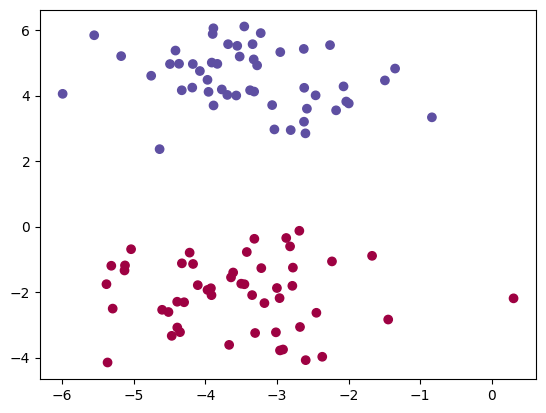

In [27]:
from sklearn.datasets import make_blobs
import numpy as np
import matplotlib.pyplot as plt


# generating two-class dataset
X, y = make_blobs(n_samples=100, centers=2, n_features=2, center_box = (-5, 5))


plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Spectral)

**(a)** Teilen Sie den Datensatz auf (70% Training, 30% Test):

- X_train: training dataset
- X_test: test dataset
- y_train: training labels
- y_test: test labels

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7)

In [29]:
# Test Cell
#----------

assert np.vstack((X_train, X_test)) in X and np.hstack((y_train, y_test)) in y
assert y_train.size/y.size == 0.7

**(b)** Verwenden Sie die sklearn-Klasse LogisticRegression um ein Modell für den Datensatz zu bilden. Trainieren Sie das Modell mit den oben festgelegten Trainingsdaten.

In [30]:
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [31]:
# Test Cell
#----------

assert type(logreg) == LogisticRegression
assert logreg.intercept_, 'Trainieren Sie das Modell mit den Daten!'

Wir visualisieren nun den Datensatz um darzustellen, wie gut unser Modell klassifiziert:

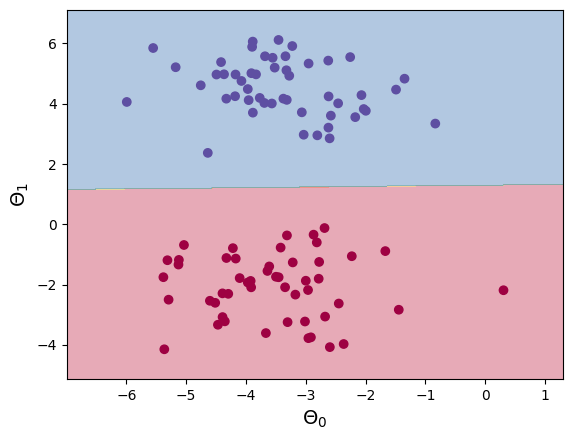

In [32]:
# Plotting decision regions
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),np.arange(y_min, y_max, 0.01))

Z = logreg.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.Spectral)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Spectral)
plt.xlabel(r"$\Theta_0$", fontsize=14)
plt.ylabel(r"$\Theta_1$", fontsize=14)
plt.show()

**(c)** Testen Sie die Vorhersagegenauigkeit (accuracy) des Modells mit den Testdaten:

In [37]:
from sklearn.metrics import accuracy_score


y_pred = logreg.predict(X_test)
acc_test = accuracy_score(y_test, y_pred) *100
print("accuracy: %.2f%%" % acc_test)

accuracy: 100.00%


In [38]:
# Test Cell
#----------

assert y_pred.shape == y_test.shape
### BEGIN HIDDEN TEST
assert acc_test == 100-np.sum(np.abs(y_pred-y_test))*100/len(y_pred)
### END HIDDEN TEST

### Multiklassen-Klassifikation
Die logistische Regression liefert uns Ergebnisse für binäre Zielvariablen. Oftmals wollen wir aber mehr als 2 Klassen unterscheiden.

Eine Möglichkeit, um Multiklassen-Klassifikation mit logistischen Regression umzusetzen, ist die sogenannte One-vs-all Klassifikation. Dabei werden für n Klassen n separate, binäre Klassifikationsprobleme definiert, bei denen jeweils nur die betrachtete Klasse den Zielwert 1 zugeteilt bekommt, und für alle anderen Klassen der Zielwert 0 angenommen wird.

Scikit-Learn unterstüzt Multiklassen-Klassifikation in der Klasse LogisticRegression über den Parameter multi_class. Setzt man : multi_class="ovr" führt die Funktion fit je eine logistische Regression für jedes Label nach dem one-vs-all (oder auch one-vs-rest, ovr) Prinzip aus.

In der folgenden Code-Zelle erzeugen wir 3 Punktwolken. Alle Punkte einer "Wolke" sollen zu einer bestimmten Klasse gehören.

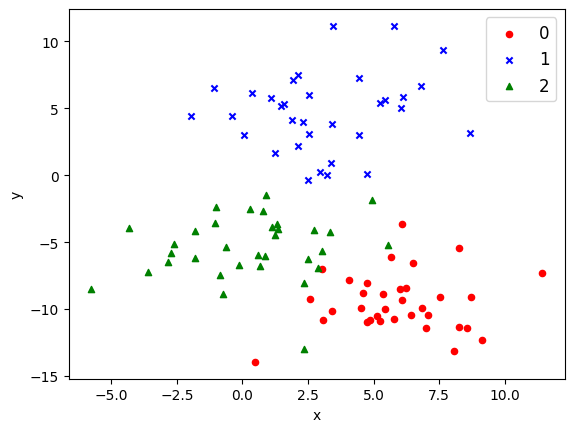

In [39]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from pandas import DataFrame
# generate 2d classification dataset
X, y = make_blobs(n_samples=100, centers=3, n_features=2, random_state=10, cluster_std=2.5)
# scatter plot, dots colored by class value
df = DataFrame(dict(x=X[:,0], y=X[:,1], label=y))
colors = {0:'red', 1:'blue', 2:'green'}
markers = {0:'o', 1:'x', 2:'^'}
fig, ax = plt.subplots()
grouped = df.groupby('label')
for key, group in grouped:
    group.plot(ax=ax, kind='scatter', x='x', y='y', label=key, marker=markers[key], color=colors[key])
    
plt.legend(loc='upper right', prop={'size': 12})
plt.savefig("LogistischeRegression20.png",transparent=True, dpi=300)
plt.show()

Nun wenden wir ein logistisches Regressionsmodell auf die Datenbasis an.

In [45]:
from typing import cast

from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state=0)

ovr_logreg = OneVsRestClassifier(LogisticRegression(solver='lbfgs'))

ovr_logreg.fit(X_train,y_train)

model = cast(LogisticRegression, ovr_logreg.estimators_[0])

model.intercept_, model.coef_

(array([-8.37789885]), array([[ 0.99195941, -0.64730259]]))

Der folgende Graph zeigt die Entscheidungsgrenzen für das Klassifikationsmodell. Alle Punkte innerhalb eines Bereiches werden der jeweiligen Klasse zugeordnet.

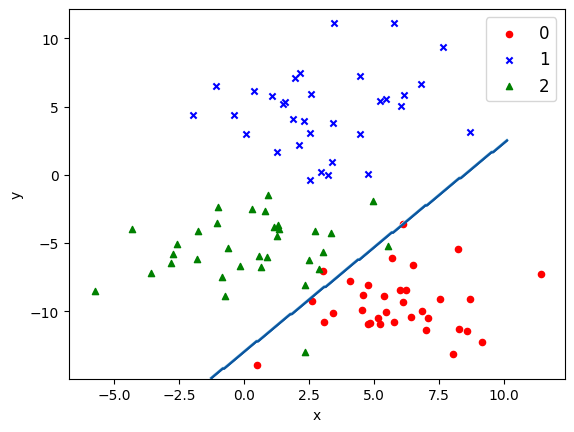

In [46]:
i=0
xx = np.linspace(X_train[:,0].min()-1, X_train[:,0].max()+1, 300)
yy = np.linspace(X_train[:,1].min()-1, X_train[:,1].max()+1, 300)
XX, YY = np.meshgrid(xx,yy)
ZZ = model.predict(np.c_[XX.ravel(), YY.ravel()])
ZZ = ZZ.reshape(XX.shape)

yyy = model.intercept_[0] + model.coef_[0][0]*xx + model.coef_[0][1]*yy

colors = {0:'red', 1:'blue', 2:'green'}
markers = {0:'o', 1:'x', 2:'^'}
fig, ax = plt.subplots()
grouped = df.groupby('label')
#plt.pcolormesh(XX, YY, ZZ, cmap=plt.cm.Set3)
for key, group in grouped:
    group.plot(ax=ax, kind='scatter', x='x', y='y', label=key, marker=markers[key], color=colors[key])
    

plt.contour(XX, YY, ZZ, cmap=plt.cm.Blues)
plt.legend(loc='upper right', prop={'size': 12})
plt.savefig("LogistischeRegression21.png",transparent=True, dpi=300)
plt.show()